In [1]:
import os
import json
import random
import string
from typing import Annotated, TypedDict, List, Sequence, Optional, Dict
from operator import add
from langchain_groq import ChatGroq 
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.types import Command
from langchain_core.messages import BaseMessage,HumanMessage,SystemMessage,AIMessage,ToolMessage
from langgraph.graph.message import add_messages
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, InjectedState, tools_condition
from dotenv import load_dotenv
from rich import print as rprint

In [2]:
load_dotenv()
api_key = os.getenv("GROQ_API_KEY")

In [3]:
llm = ChatGroq(model="llama-3.1-8b-instant")

In [4]:
def merge_dicts(left:dict, right:dict)->dict:

    if not right: return left
    if not left: return right

    def is_empty(v):
        return v is None or str(v).strip().lower() in ("none","null","")

    return {**left, **{k:v for k,v in right.items() if not is_empty(v)}}

class SupervisorState(MessagesState):
    """
        State for multi-agent system
    """   
    user_input: str
    user_intent: str

    actions_taken: str
    observations: Annotated[list, add]
    response: Annotated[list, add]
    
    complaint_data: Annotated[dict, merge_dicts]
    missing_info: list
    next: str
    customer_profile: Dict
    

In [5]:
# Supervisor Node
def supervisor_node(state:SupervisorState)->SupervisorState:

 
    history = state.get("observations", [])
    user_input = state.get("user_input")
    current_intent = state.get("user_intent", "unknown")

 
    system_prompt = f"""
    You are an intent classifier.
    
    PREVIOUS CONTEXT: {history[-3:]} # Look at last 3 interactions for speed
    CURRENT INTENT: {current_intent}

    Classify the new user message: "{user_input}"
    
    INTENTS: [inquiry, complaint, churn, unknown]

    GUIDELINES:
    - If the user is answering a question you just asked, KEEP the current intent.
    - Only change the intent if the user clearly switches topics.
    - Return ONLY the label.

    Examples:
    "hello" (with no history) → unknown
    "I don't know" (after being asked about a laptop) → complaint
    "this is bad" → unknown
    "my order is damaged" → complaint
    "I want to cancel my subscription" → churn
    "What is the price?" → inquiry
    """
    # - If the user says something like "yes", "no", or "I don't know", it is NOT 'unknown'; it belongs to the CURRENT INTENT.
    res = llm.invoke([
        {"role":"system", "content":system_prompt},
        {"role":"user", "content":state["user_input"]}
        ])
    
    intent=res.content.strip().lower()
    
    print("User Intent is ------> ", intent)
    
    return Command(goto="decision_node", update={
        "user_intent":intent,
    })


In [17]:
def fallback(state:SupervisorState)->SupervisorState:
    return {'messages':[f"Sorry, I couldn't understand your message"]}

def respond_greeting_node(state: SupervisorState) -> Command:
    user_input = state.get("user_input")
    # Check if we already know something about the user from previous turns
    observations = state.get("observations", [])
    
    # We provide context to the LLM so it doesn't repeat itself
    prompt = f"""
    You are a helpful and empathetic Customer Success Assistant.
    Context from previous interactions: {observations}
    
    Task: Greet the user warmly based on their input: "{user_input}".
    - If they just said 'Hi', ask how you can help with their product or account.
    - If they seem upset, be extra empathetic.
    - Keep it brief (1-2 sentences).
    """
    
    res = llm.invoke([SystemMessage(content=prompt)])
    
    return Command(
        goto=END, 
        update={
            "response": [res.content],
            "observations": [f"Greeted user: {res.content}"],
            "actions_taken": ["respond_greeting"]
        }
    )

In [19]:
# Worker nodes
def rag_node(state:SupervisorState)->SupervisorState:
    "Answers general user inquiries that fall outside the automated support ticket workflow."
    user_input=state.get("user_input",[])

    system_prompt="""
        You are a helpful support assistant. Provide clear, concise answers to the user's questions.
        """
    res = llm.invoke([SystemMessage(system_prompt)]+[HumanMessage(user_input)])
    
    return {'messages':res.content}

In [21]:
def build_inquiry_node():
    graph = StateGraph(SupervisorState)
    
    graph.add_node("inquiry", rag_node)

    graph.add_edge(START, "inquiry")
    graph.add_edge("inquiry", END)

    memory = MemorySaver()
    return graph.compile(checkpointer=memory)

inquiry_graph = build_inquiry_node()

def inquiry_node(state:SupervisorState)->SupervisorState:
    config = {"configurable": {"thread_id": "support_session_1"}} 
    return inquiry_graph.invoke(state, config=config)

In [22]:
user_input = {"user_input":"I need to know where is toothpaste."}

inquiry_node(user_input)

{'messages': [HumanMessage(content="Toothpaste is typically found in the bathroom, specifically in the cabinet or on a shelf near the sink. If you're in a home, you can usually find it in the bathroom cabinet. If you're in a hotel or public restroom, it may be available in a dispenser near the sink.", additional_kwargs={}, response_metadata={}, id='c99387be-66fc-4e07-a23f-bf0f0543ca63')],
 'user_input': 'I need to know where is toothpaste.',
 'observations': [],
 'response': [],
 'complaint_data': {}}

In [7]:
def extract_info_node(state:SupervisorState)->SupervisorState:
    """ 
    Extracts product, issue, and date from input into JSON.
    """
    user_input = state.get("user_input",[])

    system_prompt=f""" You are an entity extractor. 
    Your goal is to extract the product information, issue_type, and purchase_date 
    from the user's input.
    - product
    - issue_type
    - purchase_date

    Respond ONLY with a valid JSON object in this exact format:
    {{
        "product": string or null,
        "issue_type": string or null,
        "purchase_date": MM/DD/YY or null
    }}
    """
     
    res = llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_input)
        ])
    
    complaint_data = json.loads(res.content)
     
    return {"complaint_data":complaint_data}

def create_ticket_node(state:SupervisorState)->SupervisorState:
    """
    Finalizes the complaint by validating entity specificity and generating a user confirmation number.
    """
    complaint_data = state.get("complaint_data",[])
    
    prefix = ''.join(random.choices(string.ascii_uppercase,k=2))
    number1 = random.randint(100,1000)
    mid = ''.join(random.choices(string.ascii_uppercase))
    number2 = random.randint(10,100)
    ticket_id = f"{prefix}{number1}{mid}{number2}"

    ticket={
        "ticket_id":ticket_id,
        "status":"created",
        "details":complaint_data
    }
    return {"messages":f"Ticket {ticket['ticket_id']} has been created."}

def ask_missing_node(state:SupervisorState)->SupervisorState:
    """ 
    Prompts the user for specific missing details to complete the support ticket data.
    """
    
    complaint = state.get("complaint_data", {})
    missing_info = state.get("missing_info",{})
    prompt = f"The user provided: {complaint}. Politely ask for the following missing information {missing_info}."
    response = llm.invoke(prompt)

    return {"messages": [response.content],
            "missing_fields": []}
  

In [8]:
def router(state:SupervisorState)->SupervisorState:
    
    complaint_data=state.get("complaint_data",[])
    required_fields=["product", "issue_type", "purchase_date"]
    missing = [field for field in required_fields if not complaint_data.get(field)]

    if missing:
            return Command(
                goto="ask_missing_node", 
                update={
                    "missing_info": missing,
                    "complaint_data":complaint_data
                    } 
                )
    return Command(goto="create_ticket_node")
    

In [9]:
def build_complaint_graph():
    
    complaint_graph = StateGraph(SupervisorState)
    #Add Nodes
    complaint_graph.add_node('extract_info_node', extract_info_node)
    complaint_graph.add_node("ask_missing_node", ask_missing_node)
    complaint_graph.add_node("create_ticket_node",create_ticket_node)
    complaint_graph.add_node("router", router)

    #Add Edges
    complaint_graph.add_edge(START,'extract_info_node')
    complaint_graph.add_edge("extract_info_node","router")
    complaint_graph.add_edge("ask_missing_node",END)
    complaint_graph.add_edge("create_ticket_node",END)
    memory = MemorySaver()
    return complaint_graph.compile(checkpointer=memory)

complaint_graph = build_complaint_graph()

def complaint_node(state:SupervisorState)->SupervisorState:
    config = {"configurable": {"thread_id": "support_session_1"}}
    return complaint_graph.invoke(state, config=config)


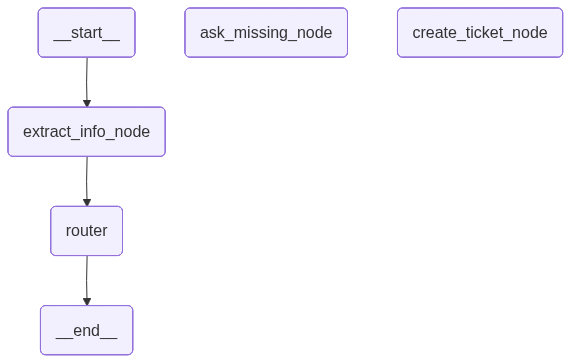

In [10]:
complaint_graph

In [11]:
usr_state = { 
    "user_input": "Oct 2, 2025."
}

In [12]:
complaint_node(usr_state)

{'messages': [HumanMessage(content="To proceed, I'll need some additional information from you. \n\nCould you please provide the following details:\n\n1. The product you are referring to (e.g., 'smartphone', 'laptop', 'furniture', etc.)?\n\n2. The type of issue you are experiencing with the product (e.g., 'defective', 'not functioning', 'missing parts', etc.)?\n\nOnce I have this information, I can help you update the provided dictionary.", additional_kwargs={}, response_metadata={}, id='1da17d74-f9e4-4876-bab8-6d33bc2d9ff1')],
 'user_input': 'Oct 2, 2025.',
 'observations': [],
 'response': [],
 'complaint_data': {'product': None,
  'issue_type': None,
  'purchase_date': '10/02/25'},
 'missing_info': ['product', 'issue_type']}

In [14]:
def churn_score_node(state:SupervisorState)->SupervisorState:
    """
        Calculate a churn risk score from user input.
        Returns category: high, medium, or low.
    """
    user_input=state['user_input']
    current_profile = state.get('customer_profile',{})
    system_prompt = """ 
    You are a churn detection assistant.
    Based on the user input, classifiy their churn risk into:
    - high: user explicitly wants to cancel, switch, or sounds very frustrated.
    - medium: user shows dissatisfaction but hasn't decided to cancel yet.
    - low: user just asking questions or mild complaints.

    Examples:
    User: "I'm cancelling this useless service today."
    Churn risk: high

    User: "Your prices keep going up, I don't know if it's worth it anymore."
    Churn risk: medium

    User: "How do I cancel if I ever need to in the future?"
    Churn risk: low

    Respond with only one of: high, medium, low.
    """
    score = llm.invoke([
        {'role':'system', 'content':system_prompt},
        {'role':'user', 'content':user_input}
    ]).content
    
    current_profile['churn_score']=score
    return {"customer_profile":current_profile}

def loyalty_score_node(state:SupervisorState)->SupervisorState:
    """ 
        Provide loyalty score to user based on churn score and customer value. 
    """
    score = state['customer_profile']['churn_score']
    current_profile = state.get('customer_profile')
    reward_weights = {'high': 1.0, "medium": 0.6, "low": 0.2}
    clv_values = {"high": 1000, "medium": 500, "low": 200}
    clv_tier=random.choices(
        ['high','medium','low'],
        weights=[0.25,0.45,0.3],
        k=1
        )[0]

    loyalty_score = reward_weights[score]*clv_values[clv_tier]
    current_profile['loyalty_score']=loyalty_score
    current_profile['clv_tier']=clv_tier

    return {'customer_profile':current_profile}

def reward_node(state:SupervisorState)->SupervisorState:
    """
    Generate a personalized reward offers.
    """

    user_input=state['user_input']
    churn_score=state['customer_profile']['churn_score']
    loyalty_score=state['customer_profile']['loyalty_score']

    system_prompt=""" 
    You are a customer retention assistant. 
    Generate a polite, empathetic message based on the following:
    - The user's message
    - Their churn risk (high, medium, low)
    - Their loyalty score (40-1000)

    Rules:
    - If loyalty score >= 800 → emphasize strong appreciation and give a high reward (e.g., big discount, free premium month).
    - If 500-799 → show gratitude and offer a medium reward (e.g., discount or perk).
    - If 200-499 → acknowledge their value and give a small reward (e.g., loyalty points or small discount).
    - If < 200 → do not give a reward, just apologize and promise to improve.
    - If churn risk = high → always start by apologizing and showing empathy before mentioning any reward.
    - Keep the message short, friendly, concise and natural. Do not include technical terms or scores.
    
    Respond with only the final concise message.
    """

    user_context = f"""
        User message: {user_input}
        Churn risk: {churn_score}
        Loyalty score: {loyalty_score}
        """

    response = llm.invoke([{'role':'system', 'content':system_prompt},
                           {'role':'user','content':user_context}])
    
    return {"messages":response.content}


In [15]:
def build_retention_graph():

    graph = StateGraph(SupervisorState)

    graph.add_node("churn_score",churn_score_node)
    graph.add_node("evaluate_user_value",loyalty_score_node)
    graph.add_node("offer_reward",reward_node)

    graph.add_edge(START, "churn_score")
    graph.add_edge("churn_score", "evaluate_user_value")
    graph.add_edge("evaluate_user_value", "offer_reward")
    graph.add_edge("offer_reward", END)
    memory=MemorySaver()
    return graph.compile(checkpointer=memory)

In [41]:
retention_graph = build_retention_graph()

def retention_node(state:SupervisorState)->SupervisorState:
    config= {"configurable":{"thread_id":"user_complaint_session", "recursion_limit":5}}
    return retention_graph.invoke(state, config=config)

In [44]:
usr_input={"user_input":"I have problem with this phone. and you are the worst."}

In [45]:
retention_node(usr_input)

{'messages': [HumanMessage(content='"Hi there, so sorry to hear you\'re having issues with your phone. Your loyalty means the world to us, and as a valued customer, we\'d like to offer you a complimentary premium upgrade for a month as a token of appreciation. We\'ll get this sorted out for you ASAP. Thanks for sticking with us!"', additional_kwargs={}, response_metadata={}, id='2fe06a25-be0a-4821-a931-e31fd9ac5c9f'),
  HumanMessage(content='"I\'m so sorry to hear you\'re having trouble with your phone and that you\'re feeling frustrated with us. We value your loyalty and appreciate the time you\'ve spent with us. As a small gesture of apology, we\'d like to offer you 10% off your next purchase. If you\'d like, I can also help troubleshoot the issue with your phone. Please let me know how I can assist you further."', additional_kwargs={}, response_metadata={}, id='84633fd4-9b43-4dab-a9b0-a341bab4a74d')],
 'user_input': 'I have problem with this phone. and you are the worst.',
 'observa